# Network-based Feature Engineering

*STRING Network Stats*
number of nodes:	1112
number of edges:	34967
average node degree:	62.3
avg. local clustering coefficient:	0.447
expected number of edges:	15277
PPI enrichment p-value:	< 1.0e-16

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
nx.__version__

'3.4.2'

## Data import

In [3]:
# Import the data
string_interactions = pd.read_csv("../data/tarca-et-al-2021/string_interactions.tsv", delimiter = "\t")
string_interactions

,#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
0,A2M,DCN,9606.ENSP00000323929,9606.ENSP00000052754,0.0,0.0,0.000,0.000,0.181,0.000,0.0,0.337,0.434
1,A2M,CPB2,9606.ENSP00000323929,9606.ENSP00000181383,0.0,0.0,0.000,0.000,0.161,0.294,0.0,0.696,0.805
2,A2M,SERPIND1,9606.ENSP00000323929,9606.ENSP00000215727,0.0,0.0,0.000,0.000,0.143,0.000,0.0,0.743,0.771
3,A2M,CTSG,9606.ENSP00000323929,9606.ENSP00000216336,0.0,0.0,0.000,0.000,0.045,0.127,0.0,0.449,0.501
4,A2M,F9,9606.ENSP00000323929,9606.ENSP00000218099,0.0,0.0,0.000,0.000,0.087,0.127,0.0,0.339,0.428
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69929,ZAP70,GRAP2,9606.ENSP00000264972,9606.ENSP00000339186,0.0,0.0,0.000,0.000,0.315,0.100,0.5,0.925,0.974
69930,ZAP70,PTPN11,9606.ENSP00000264972,9606.ENSP00000489597,0.0,0.0,0.000,0.000,0.067,0.097,0.9,0.856,0.986
69931,ZAP70,FYN,9606.ENSP00000264972,9606.ENSP00000346671,0.0,0.0,0.085,0.723,0.128,0.339,0.9,0.892,0.993
69932,ZAP70,SHC1,9606.ENSP00000264972,9606.ENSP00000401303,0.0,0.0,0.000,0.000,0.053,0.637,0.9,0.944,0.997


*Explanation of scores from the string_interactions table*
nscore - neighborhood score, (computed from the inter-gene nucleotide count).
fscore - fusion score (derived from fused proteins in other species).
pscore - cooccurence score of the phyletic profile (derived from similar absence/presence patterns of genes).
hscore - homology score, the degree of homology of the interactors (normally not reported in STRING).
ascore - coexpression score (derived from similar pattern of mRNA expression measured by DNA arrays and similar technologies).
escore - experimental score (derived from experimental data, such as, affinity chromatography).
dscore - database score (derived from curated data of various databases).
tscore - textmining score (derived from the co-occurrence of gene/protein names in abstracts).

In [4]:
string_mapping = pd.read_csv("../data/tarca-et-al-2021/string_mapping.tsv", delimiter = "\t")
string_mapping

,#queryIndex,queryItem,stringId,preferredName,annotation
0,1,P0C0L4,9606.ENSP00000396688,C4A,Complement C4-A alpha chain; Non-enzymatic com...
1,2,P0C0L5,9606.ENSP00000415941,C4B,Complement C4-B alpha chain; Non-enzymatic com...
2,3,P03951,9606.ENSP00000384957,F11,Coagulation factor XIa heavy chain; Factor XI ...
3,4,Q9Y4X3,9606.ENSP00000259631,CCL27,C-C motif chemokine 27; Chemotactic factor tha...
4,5,P39060,9606.ENSP00000352798,COL18A1,Collagen alpha-1(XVIII) chain; Probably plays ...
...,...,...,...,...,...
1168,1181,P12931,9606.ENSP00000362680,SRC,Proto-oncogene tyrosine-protein kinase Src; No...
1169,1182,P31948,9606.ENSP00000351646,STIP1,Stress-induced-phosphoprotein 1; Acts as a co-...
1170,1183,Q08629,9606.ENSP00000378401,SPOCK1,Testican-1; May play a role in cell-cell and c...
1171,1184,Q92563,9606.ENSP00000321108,SPOCK2,Testican-2; May participate in diverse steps o...


In [5]:
string_kmeans_clusters = pd.read_csv("../data/tarca-et-al-2021/string_kmeans_clusters.tsv", delimiter = "\t")
string_kmeans_clusters

,#clustering method,cluster number,cluster color,hex color,gene count,protein name,protein identifier,protein description
0,kmeans,1,Red,#ff0000,411,ABL1,9606.ENSP00000361423,Tyrosine-protein kinase ABL1; Non-receptor tyr...
1,kmeans,1,Red,#ff0000,411,ABL2,9606.ENSP00000427562,Tyrosine-protein kinase ABL2; Non-receptor tyr...
2,kmeans,1,Red,#ff0000,411,ACVR1B,9606.ENSP00000442656,Activin receptor type-1B; Transmembrane serine...
3,kmeans,1,Red,#ff0000,411,ACVRL1,9606.ENSP00000373574,Serine/threonine-protein kinase receptor R3; T...
4,kmeans,1,Red,#ff0000,411,ADAM12,9606.ENSP00000357668,Disintegrin and metalloproteinase domain-conta...
...,...,...,...,...,...,...,...,...
1107,kmeans,8,Light Sky Blue,#65c7ff,3,EDAR,9606.ENSP00000258443,Tumor necrosis factor receptor superfamily mem...
1108,kmeans,9,Medium Blue,#001cb2,2,CNDP1,9606.ENSP00000351682,Carnosine dipeptidase 1; Belongs to the peptid...
1109,kmeans,9,Medium Blue,#001cb2,2,CNDP2,9606.ENSP00000325548,Cytosolic non-specific dipeptidase; Hydrolyzes...
1110,kmeans,10,Purple,#9665ff,2,UFC1,9606.ENSP00000356982,Ubiquitin-fold modifier-conjugating enzyme 1; ...


In [6]:
string_kmeans_cluster_desc = pd.read_csv("../data/tarca-et-al-2021/string_kmeans_cluster_descriptions.tsv", delimiter = "\t")
string_kmeans_cluster_desc

,#clustering method,cluster number,cluster color,hex color,gene count,primary description,secondary description,tertiary description,protein names
0,kmeans,1,Red,#ff0000,411,Transmembrane receptor protein tyrosine kinase...,-,-,"FGF23, FGFR1, FGF16, FGFR2, FGF1, IGF1R, CDH5,..."
1,kmeans,2,Brown,#ffaf65,387,Positive regulation of immune system process,Extracellular matrix,Secreted,"NOTCH1, B2M, FGA, HAMP, CTLA4, SELL, KNG1, CFL..."
2,kmeans,3,Dark Golden Rod,#b2ab00,274,Cytokine-cytokine receptor interaction,Cytokine-mediated signaling pathway,-,"IL17A, SPTAN1, EIF4A3, RAD51, CCNA2, TK1, SOD2..."
3,kmeans,4,Green Yellow,#bbff65,11,Negative regulation of TCF-dependent signaling...,-,-,"DKK3, DKK1, MATN3, WNT7A, WIF1, FRZB, DKK4, KR..."
4,kmeans,5,Green 2,#0eb200,11,Purine metabolism,-,-,"ADSL, ENTPD1, PDE7A, PDE5A, IMPDH2, IMPDH1, PD..."
5,kmeans,6,Green,#65ffa3,7,Neurexins and neuroligins,-,-,"NRXN3, NRXN1, SPARCL1, LRRTM1, NXPH1, NLGN4X, ..."
6,kmeans,7,Blue,#00b29d,4,Glycosaminoglycan degradation,Mucopolysaccharidoses,-,"IDS, ARSB, IDUA, ARSA"
7,kmeans,8,Light Sky Blue,#65c7ff,3,TNFs bind their physiological receptors,"Ectodermal dysplasia 1, and Geleophysic dyspla...",-,"EDA, EDA2R, EDAR"
8,kmeans,9,Medium Blue,#001cb2,2,Histidine metabolism,Metallodipeptidase activity,Carboxypeptidase,"CNDP2, CNDP1"
9,kmeans,10,Purple,#9665ff,2,Protein K69-linked ufmylation,-,-,"UFC1, UFM1"


In [7]:
go = pd.read_csv("../data/tarca-et-al-2021/enrichment.GO.BioProcess.tsv", delimiter = "\t")
go

,#term ID,term description,observed gene count,background gene count,strength,signal,false discovery rate,matching proteins in your network (IDs),matching proteins in your network (labels)
0,GO:0050896,Response to stimulus,890,7835,0.30,1.41,1.500000e-148,"9606.ENSP00000006053,9606.ENSP00000008938,9606...","CX3CL1,PGLYRP1,CD4,RTN4R,TNFRSF17,GRN,TNFRSF1A..."
1,GO:0048583,Regulation of response to stimulus,621,3931,0.44,1.92,2.130000e-136,"9606.ENSP00000006053,9606.ENSP00000008938,9606...","CX3CL1,PGLYRP1,CD4,RTN4R,DCN,GRN,CD22,TNFRSF1A..."
2,GO:0007166,Cell surface receptor signaling pathway,451,2040,0.59,2.63,4.000000e-134,"9606.ENSP00000006053,9606.ENSP00000011653,9606...","CX3CL1,CD4,RTN4R,TNFRSF17,TNFRSF1A,FGF4,FGF20,..."
3,GO:0048518,Positive regulation of biological process,770,6207,0.34,1.53,2.920000e-131,"9606.ENSP00000006053,9606.ENSP00000011653,9606...","CX3CL1,CD4,RTN4R,DCN,GRN,PRSS22,TNFRSF1A,FSTL3..."
4,GO:0070887,Cellular response to chemical stimulus,491,2609,0.52,2.26,1.700000e-124,"9606.ENSP00000006053,9606.ENSP00000011653,9606...","CX3CL1,CD4,TNFRSF17,TNFRSF1A,FGF4,FGF20,CPB2,G..."
...,...,...,...,...,...,...,...,...,...
2385,GO:0055088,Lipid homeostasis,18,161,0.29,0.28,4.870000e-02,"9606.ENSP00000221930,9606.ENSP00000233242,9606...","TGFB1,APOB,APOA1,NR1D1,APOE,GCKR,FGFR4,ANGPTL4..."
2386,GO:0061298,Retina vasculature development in camera-type eye,5,19,0.66,0.32,4.870000e-02,"9606.ENSP00000261799,9606.ENSP00000265371,9606...","PDGFRB,NRP1,BMPR2,ACVRL1,LAMA1"
2387,GO:0097094,Craniofacial suture morphogenesis,5,19,0.66,0.32,4.870000e-02,"9606.ENSP00000168712,9606.ENSP00000221930,9606...","FGF4,TGFB1,TGFB3,MMP16,MMP14"
2388,GO:2000136,Regulation of cell proliferation involved in h...,5,19,0.66,0.32,4.870000e-02,"9606.ENSP00000295379,9606.ENSP00000362608,9606...","BMP10,PIM1,BMPR2,NACA,NOTCH1"


In [8]:
kegg = pd.read_csv("../data/tarca-et-al-2021/enrichment.KEGG.tsv", delimiter = "\t")
kegg

,#term ID,term description,observed gene count,background gene count,strength,signal,false discovery rate,matching proteins in your network (IDs),matching proteins in your network (labels)
0,hsa04060,Cytokine-cytokine receptor interaction,171,282,1.03,5.99,1.550000e-97,"9606.ENSP00000006053,9606.ENSP00000011653,9606...","CX3CL1,CD4,TNFRSF17,RELT,TNFRSF1A,OSM,CCL22,CC..."
1,hsa04151,PI3K-Akt signaling pathway,126,349,0.80,3.45,7.380000e-51,"9606.ENSP00000168712,9606.ENSP00000180166,9606...","FGF4,FGF20,OSM,MAPK1,CDC37,EPOR,HGF,LAMB1,CSF3..."
2,hsa05200,Pathways in cancer,138,515,0.67,2.65,1.810000e-43,"9606.ENSP00000168712,9606.ENSP00000180166,9606...","FGF4,FGF20,GSTA3,MAPK1,BIRC7,MMP2,TGFB1,EPOR,H..."
3,hsa04010,MAPK signaling pathway,98,286,0.78,3.05,8.670000e-38,"9606.ENSP00000162749,9606.ENSP00000168712,9606...","TNFRSF1A,FGF4,FGF20,MAPK13,MAPK12,MAPK1,TAB1,T..."
4,hsa04061,Viral protein interaction with cytokine and cy...,63,96,1.06,4.48,1.610000e-36,"9606.ENSP00000006053,9606.ENSP00000162749,9606...","CX3CL1,TNFRSF1A,CCL22,CCL17,TNFRSF10A,CCL2,CCL..."
...,...,...,...,...,...,...,...,...,...
177,hsa04923,Regulation of lipolysis in adipocytes,8,54,0.42,0.33,3.350000e-02,"9606.ENSP00000256592,9606.ENSP00000263967,9606...","TSHB,PIK3CA,INSR,PRKACA,PTGS2,NPPA,INS,PIK3R1"
178,hsa04924,Renin secretion,9,66,0.38,0.32,3.590000e-02,"9606.ENSP00000234310,9606.ENSP00000272190,9606...","PPP3R1,REN,PRKACA,CTSB,PDE3A,AGT,NPPA,PPP3CA,A..."
179,hsa00592,alpha-Linolenic acid metabolism,5,25,0.55,0.33,3.890000e-02,"9606.ENSP00000312286,9606.ENSP00000364249,9606...","PLA2G1B,PLA2G5,PLA2G2E,PLA2G2A,PLA2G10"
180,hsa00565,Ether lipid metabolism,7,47,0.42,0.30,4.670000e-02,"9606.ENSP00000274793,9606.ENSP00000312286,9606...","PLA2G7,PLA2G1B,PLA2G5,PLA2G2E,PLA2G2A,PLA2G10,..."


## Network analysis

In [9]:
# Convert the data into a data frame
df = pd.DataFrame(string_interactions, columns = ['#node1', 'node2'])
df

,#node1,node2
0,A2M,DCN
1,A2M,CPB2
2,A2M,SERPIND1
3,A2M,CTSG
4,A2M,F9
...,...,...
69929,ZAP70,GRAP2
69930,ZAP70,PTPN11
69931,ZAP70,FYN
69932,ZAP70,SHC1


In [10]:
# Read a graph from pandas df containing an edgelist
graph = nx.from_pandas_edgelist(df, source = "#node1", target = "node2")

In [ ]:
# Count the number of nodes
nx.number_of_nodes(graph) # 1112 proteins
# Count the number of edges
nx.number_of_edges(graph) # 34967 interactions

1112

>The degree (or connectivity) of a node is the number of links it has to other nodes. 
-> the equivalent of a rowsum in a hypergraph?

>*Degree distribution of a network*
>Most real networks (natural and artificial) do not have a random degree distribution (where the majority of nodes have average degree).
>-> scale-free networks: the majority of nodes have low degree and a few nodes have high degree (hubs)

In [16]:
# Degree of all nodes
nx.degree(graph)


DegreeView({'A2M': 135, 'DCN': 116, 'CPB2': 58, 'SERPIND1': 60, 'CTSG': 92, 'F9': 56, 'TIMP1': 192, 'ACP5': 43, 'MMP2': 211, 'PLAT': 121, 'TGFB1': 326, 'PON1': 50, 'SERPINE1': 198, 'C1QBP': 37, 'CCL2': 304, 'AFM': 40, 'IL2': 296, 'IL4': 290, 'LTF': 108, 'HRG': 61, 'APOB': 133, 'AZU1': 34, 'PROC': 45, 'CTSD': 78, 'MMP8': 68, 'APOA1': 128, 'C3': 146, 'CFP': 53, 'APOE': 199, 'CRP': 227, 'APCS': 75, 'MMP7': 109, 'MMP13': 92, 'THBS1': 183, 'VWF': 210, 'PDGFRB': 185, 'TIMP2': 110, 'LGALS3BP': 35, 'IL1A': 290, 'IL1B': 424, 'C9': 55, 'FGF2': 253, 'KLKB1': 63, 'HPX': 68, 'ITIH4': 87, 'TIMP3': 88, 'MFGE8': 42, 'AHSG': 100, 'EGFR': 378, 'IGFBP1': 54, 'SERPING1': 83, 'MMP10': 38, 'APP': 211, 'ADAMTS1': 26, 'ALB': 382, 'PF4': 133, 'MASP1': 51, 'MMP3': 162, 'LRP8': 27, 'CXCL10': 225, 'FGB': 86, 'CXCL8': 330, 'F2': 122, 'PRSS1': 35, 'PLG': 181, 'LEP': 197, 'KLK3': 62, 'CLU': 119, 'SERPINF2': 73, 'C7': 32, 'MMP1': 148, 'SERPINA4': 34, 'CST3': 89, 'SHBG': 46, 'SPARCL1': 28, 'RBP4': 46, 'KLK13': 13, 'AI

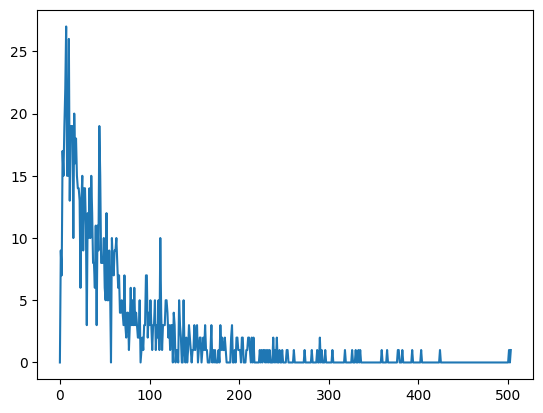

In [21]:
plt.plot(nx.degree_histogram(graph))
# X-axis = Degree
# Y-axis = Frequency of degree
plt.savefig('../output/tarca_et_al_2021/degree-histogram.png')

In [22]:
degrees = dict(nx.degree(graph))
hub = max(degrees, key = degrees.get)
print("This network contains a hub", hub, "with a degree of", degrees[hub])

This network contains a hub TNF with a degree of 503


The degree is essentially an equivalent of a rowsum in a hypergraph! See below after calculating rowsums and checking the max (max = 503). 

>*Betweenness centrality*
>Betweenness centrality measures the number of shortest paths between all pairs of nodes that pass through that node. 
>- nodes with high betweenness centrality act as bridges or bottlenecks for the transfer of information through the network

In [18]:
nx.betweenness_centrality(graph)

{'A2M': 0.00296242426172247,
 'DCN': 0.004354266714244512,
 'CPB2': 0.000343244723895674,
 'SERPIND1': 0.00016765998977757253,
 'CTSG': 0.0009988923834381457,
 'F9': 0.0011801235594495396,
 'TIMP1': 0.002144554158244624,
 'ACP5': 0.00022182659882352102,
 'MMP2': 0.004049867890134652,
 'PLAT': 0.001197770675002444,
 'TGFB1': 0.01382504395540899,
 'PON1': 0.00016375490360720073,
 'SERPINE1': 0.004535587738418874,
 'C1QBP': 0.0004027499371685063,
 'CCL2': 0.00600530451545959,
 'AFM': 8.575508348773031e-05,
 'IL2': 0.007710060268344198,
 'IL4': 0.004545626363382402,
 'LTF': 0.003981977725393831,
 'HRG': 0.0002667112573588367,
 'APOB': 0.005194072545719269,
 'AZU1': 0.00024107109319487687,
 'PROC': 0.00010150578186258532,
 'CTSD': 0.0017809365866779437,
 'MMP8': 0.00047052390573591236,
 'APOA1': 0.0027824069361287334,
 'C3': 0.0024900689036890518,
 'CFP': 0.00043585397035167416,
 'APOE': 0.00510668302713708,
 'CRP': 0.0052336471682847534,
 'APCS': 0.0006319091941517958,
 'MMP7': 0.001203327

>*Closeness centrality*
>Closeness centrality is a measure of the distance between a node and all other nodes of the network. 
>- highly central nodes can have more influence on the network

In [19]:
nx.closeness_centrality(graph)

{'A2M': 0.5056895766954939,
 'DCN': 0.49487750556792875,
 'CPB2': 0.42599693251533743,
 'SERPIND1': 0.4279661016949153,
 'CTSG': 0.47397610921501704,
 'F9': 0.4367138364779874,
 'TIMP1': 0.5265402843601896,
 'ACP5': 0.47076271186440677,
 'MMP2': 0.5374939525882922,
 'PLAT': 0.5063810391978122,
 'TGFB1': 0.5771428571428572,
 'PON1': 0.45890128046261874,
 'SERPINE1': 0.5298044825941821,
 'C1QBP': 0.4419252187748608,
 'CCL2': 0.5685772773797338,
 'AFM': 0.42179195140470765,
 'IL2': 0.5642458100558659,
 'IL4': 0.5633874239350912,
 'LTF': 0.49531876950512704,
 'HRG': 0.4292890262751159,
 'APOB': 0.5082342177493138,
 'AZU1': 0.4250191277735272,
 'PROC': 0.4123979213066073,
 'CTSD': 0.4898589065255732,
 'MMP8': 0.47580299785867236,
 'APOA1': 0.5089326614750344,
 'C3': 0.5054595086442221,
 'CFP': 0.44122319301032564,
 'APOE': 0.5338779432964921,
 'CRP': 0.5382751937984496,
 'APCS': 0.4701650444350402,
 'MMP7': 0.5022603978300181,
 'MMP13': 0.49029126213592233,
 'THBS1': 0.5270398481973435,
 'V

>*Biological interpretation*
> Hubs tend to be essential nodes; their selective attack leads to rapid deterioration of information transfer.
> Peripheral nodes tend to make better drug targets.
> Biological networks often have a modular structure (groups of nodes that are more intensely connected to each other than to other groups).
> Modules of molecular networks encode biological functions.
> Bridges may be important regulators between different functions.
> Central nodes may have stronger control properties on the system

In [25]:
# Identify a diameter of a network
nx.diameter(graph)

5

What is a diameter of a network?

In [20]:
# Count the number of cliques (a complete subgraph where all nodes are connected)
nx.number_of_cliques(graph)

{'A2M': 3829,
 'DCN': 910,
 'CPB2': 765,
 'SERPIND1': 588,
 'CTSG': 772,
 'F9': 395,
 'TIMP1': 12573,
 'ACP5': 93,
 'MMP2': 18373,
 'PLAT': 2887,
 'TGFB1': 62681,
 'PON1': 139,
 'SERPINE1': 15888,
 'C1QBP': 51,
 'CCL2': 53449,
 'AFM': 188,
 'IL2': 42936,
 'IL4': 42117,
 'LTF': 1057,
 'HRG': 663,
 'APOB': 2291,
 'AZU1': 69,
 'PROC': 223,
 'CTSD': 412,
 'MMP8': 269,
 'APOA1': 2411,
 'C3': 5471,
 'CFP': 183,
 'APOE': 11704,
 'CRP': 15724,
 'APCS': 637,
 'MMP7': 843,
 'MMP13': 738,
 'THBS1': 11733,
 'VWF': 11109,
 'PDGFRB': 14432,
 'TIMP2': 2120,
 'LGALS3BP': 84,
 'IL1A': 40664,
 'IL1B': 81773,
 'C9': 764,
 'FGF2': 48192,
 'KLKB1': 346,
 'HPX': 755,
 'ITIH4': 499,
 'TIMP3': 476,
 'MFGE8': 87,
 'AHSG': 1389,
 'EGFR': 67331,
 'IGFBP1': 144,
 'SERPING1': 1290,
 'MMP10': 47,
 'APP': 5547,
 'ADAMTS1': 19,
 'ALB': 56775,
 'PF4': 3492,
 'MASP1': 159,
 'MMP3': 5196,
 'LRP8': 34,
 'CXCL10': 20545,
 'FGB': 833,
 'CXCL8': 50411,
 'F2': 2805,
 'PRSS1': 69,
 'PLG': 8283,
 'LEP': 6636,
 'KLK3': 139,
 'C

In [35]:
# Find the largest clique
max(nx.find_cliques(graph), key = len)

['TNF',
 'IL6',
 'IL1B',
 'IFNG',
 'IL10',
 'CD4',
 'IL4',
 'CXCL8',
 'IL1A',
 'CCL2',
 'IL17A',
 'CSF2',
 'IL13',
 'CCL5',
 'CXCL10',
 'CCL3',
 'ICAM1',
 'IL2',
 'CXCL1',
 'CSF3',
 'PECAM1',
 'CXCL12',
 'VCAM1',
 'MMP9',
 'TGFB1',
 'ALB',
 'GAPDH',
 'LEP',
 'BCL2',
 'FN1',
 'PTGS2',
 'MMP2',
 'INS',
 'CASP3',
 'MAPK3',
 'FGF2',
 'IGF1',
 'HGF',
 'FGF7',
 'MMP3',
 'FGF6',
 'FGF17',
 'FGF18',
 'FGF16',
 'FGF5',
 'FGF20',
 'FGF10',
 'FGF8',
 'FGF4',
 'FGF9',
 'TIMP1',
 'SERPINE1']

In [29]:
print(nx.average_clustering(graph))

0.4425899792320728


In [ ]:
adj_matrix = print(nx.adjacency_matrix(graph))
adj_matrix

<Compressed Sparse Row sparse array of dtype 'int64'
	with 69934 stored elements and shape (1112, 1112)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 6)	1
  (0, 7)	1
  (0, 8)	1
  (0, 9)	1
  (0, 10)	1
  (0, 11)	1
  (0, 12)	1
  (0, 13)	1
  (0, 14)	1
  (0, 15)	1
  (0, 16)	1
  (0, 17)	1
  (0, 18)	1
  (0, 19)	1
  (0, 20)	1
  (0, 21)	1
  (0, 22)	1
  (0, 23)	1
  (0, 24)	1
  (0, 25)	1
  :	:
  (1105, 709)	1
  (1105, 855)	1
  (1105, 891)	1
  (1105, 943)	1
  (1106, 38)	1
  (1106, 385)	1
  (1106, 919)	1
  (1106, 924)	1
  (1106, 968)	1
  (1106, 1062)	1
  (1107, 123)	1
  (1107, 597)	1
  (1107, 767)	1
  (1108, 589)	1
  (1108, 730)	1
  (1108, 767)	1
  (1108, 816)	1
  (1108, 889)	1
  (1109, 764)	1
  (1109, 1110)	1
  (1110, 355)	1
  (1110, 616)	1
  (1110, 815)	1
  (1110, 1109)	1
  (1111, 726)	1


In [58]:
adj_df = nx.to_pandas_adjacency(graph)
adj_df

,A2M,DCN,CPB2,SERPIND1,CTSG,F9,TIMP1,ACP5,MMP2,PLAT,...,NR1D1,HDGFL2,HIPK3,IGFBP6,IL1RAPL2,LGALS2,LIN7B,UFC1,UFM1,SCARF2
A2M,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DCN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPB2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SERPIND1,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CTSG,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LGALS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LIN7B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
UFC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
UFM1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [59]:
row_sums = adj_df.sum(axis = 1)
row_sums

A2M         135.0
DCN         116.0
CPB2         58.0
SERPIND1     60.0
CTSG         92.0
            ...  
LGALS2        3.0
LIN7B         5.0
UFC1          2.0
UFM1          4.0
SCARF2        1.0
Length: 1112, dtype: float64

In [60]:
adj_df['rowsums'] = adj_df.sum(axis = 1)
adj_df = adj_df.iloc[:, -1:]
adj_df

,rowsums
A2M,135.0
DCN,116.0
CPB2,58.0
SERPIND1,60.0
CTSG,92.0
...,...
LGALS2,3.0
LIN7B,5.0
UFC1,2.0
UFM1,4.0


In [61]:
adj_df['rank'] = adj_df['rowsums'].rank() # default method = average, like the one used in R
adj_df

C:\Users\doram\AppData\Local\Temp\ipykernel_12536\2392373768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adj_df['rank'] = adj_df['rowsums'].rank() # default method = average, like the one used in R


,rowsums,rank
A2M,135.0,985.5
DCN,116.0,937.0
CPB2,58.0,697.5
SERPIND1,60.0,714.0
CTSG,92.0,854.5
...,...,...
LGALS2,3.0,25.0
LIN7B,5.0,58.0
UFC1,2.0,13.0
UFM1,4.0,41.0


In [62]:
adj_df['norm_rank'] = adj_df['rank'] / 1112
adj_df

C:\Users\doram\AppData\Local\Temp\ipykernel_12536\3467439474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adj_df['norm_rank'] = adj_df['rank'] / 1112


,rowsums,rank,norm_rank
A2M,135.0,985.5,0.886241
DCN,116.0,937.0,0.842626
CPB2,58.0,697.5,0.627248
SERPIND1,60.0,714.0,0.642086
CTSG,92.0,854.5,0.768435
...,...,...,...
LGALS2,3.0,25.0,0.022482
LIN7B,5.0,58.0,0.052158
UFC1,2.0,13.0,0.011691
UFM1,4.0,41.0,0.036871


In [ ]:
adj_df.index.name = 'gene'
adj_df.reset_index(inplace=True)
adj_df

,gene,rowsums,rank,norm_rank
0,A2M,135.0,985.5,0.886241
1,DCN,116.0,937.0,0.842626
2,CPB2,58.0,697.5,0.627248
3,SERPIND1,60.0,714.0,0.642086
4,CTSG,92.0,854.5,0.768435
...,...,...,...,...
1107,LGALS2,3.0,25.0,0.022482
1108,LIN7B,5.0,58.0,0.052158
1109,UFC1,2.0,13.0,0.011691
1110,UFM1,4.0,41.0,0.036871


In [65]:
adj_df.to_csv("../output/tarca_et_al_2021/somamer_target_hypergraph.csv")